# Waveform Construction Using Fourier Series

**Course:** Biomedical Signal Processing  
**Topic:** Fourier Series Waveform Synthesis

---

## Objectives

1. Reconstruct **square**, **triangle**, and **sawtooth** waves from their Fourier series
2. Evaluate reconstruction accuracy via **RMS error** as harmonic count increases (N = 1 → 400)
3. Visualize convergence behavior and the **Gibbs phenomenon**

## 1. Imports and Setup

In [1]:
import sys
from pathlib import Path

# Ensure the project root is on the Python path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.square_wave import square_reference, square_fourier
from src.triangle_wave import triangle_reference, triangle_fourier
from src.sawtooth_wave import sawtooth_reference, sawtooth_fourier
from src.metrics import rms_error

# Directories
FIGURES_DIR = PROJECT_ROOT / "figures"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Signal Parameters

In [2]:
fs = 1000          # Sampling frequency [Hz]
duration = 1.0     # Duration [s]
f0 = 5.0           # Fundamental frequency [Hz]
A = 1.0            # Amplitude
N_max = 400        # Maximum harmonic count

t = np.linspace(0, duration, fs)

print(f"Time vector: {len(t)} samples, {t[0]:.3f} – {t[-1]:.3f} s")
print(f"Fundamental frequency: {f0} Hz")
print(f"Max harmonics: {N_max}")

Time vector: 1000 samples, 0.000 – 1.000 s
Fundamental frequency: 5.0 Hz
Max harmonics: 400


## 3. Reference Signals

Generate ground-truth waveforms using SciPy.

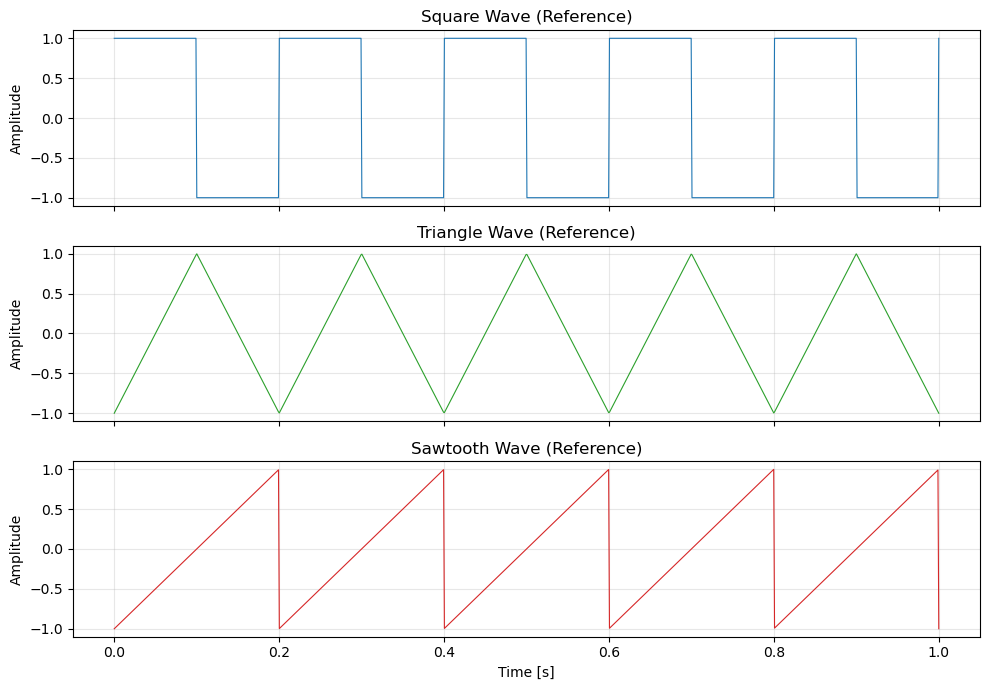

In [3]:
sq_ref = square_reference(t, f0, A)
tri_ref = triangle_reference(t, f0, A)
saw_ref = sawtooth_reference(t, f0, A)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t, sq_ref, linewidth=0.8, color="tab:blue")
axes[0].set_title("Square Wave (Reference)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, tri_ref, linewidth=0.8, color="tab:green")
axes[1].set_title("Triangle Wave (Reference)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, saw_ref, linewidth=0.8, color="tab:red")
axes[2].set_title("Sawtooth Wave (Reference)")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 4. Waveform Reconstruction Plots

For each waveform, compare the reference with Fourier reconstructions at N = 5, 20, and 100 harmonics.

In [17]:
harmonics_to_show = [5, 20, 100]

def plot_reconstruction(t, ref, fourier_func, title, save_path, f0=5.0, A=1.0):
    """Plot reference vs Fourier reconstructions: one subplot per N, plus a combined view."""
    colors = ['tab:orange', 'tab:green', 'tab:blue']

    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

    # Individual harmonic subplots
    for i, (N_h, color) in enumerate(zip(harmonics_to_show, colors)):
        x_recon = fourier_func(t, N_h, f0, A)
        axes[i].plot(t, ref, 'k--', linewidth=1.0, alpha=0.5, label='Reference')
        axes[i].plot(t, x_recon, linewidth=0.8, color=color, label=f'N = {N_h}')
        axes[i].set_title(f'{title} – N = {N_h}')
        axes[i].set_ylabel('Amplitude')
        axes[i].legend(loc='upper right')
        axes[i].grid(True, alpha=0.3)

    # Combined subplot
    axes[3].plot(t, ref, 'k--', linewidth=1.0, alpha=0.5, label='Reference')
    for N_h, color in zip(harmonics_to_show, colors):
        x_recon = fourier_func(t, N_h, f0, A)
        axes[3].plot(t, x_recon, linewidth=0.8, color=color, label=f'N = {N_h}')
    axes[3].set_title(f'{title} – Combined')
    axes[3].set_xlabel('Time [s]')
    axes[3].set_ylabel('Amplitude')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    print(f"Saved to {save_path}")
    plt.show()
    return fig

Saved to /home/Plutonium/Documents/Biosignals/homeworks/fourier_wave_synthesis/figures/square_reconstruction.png


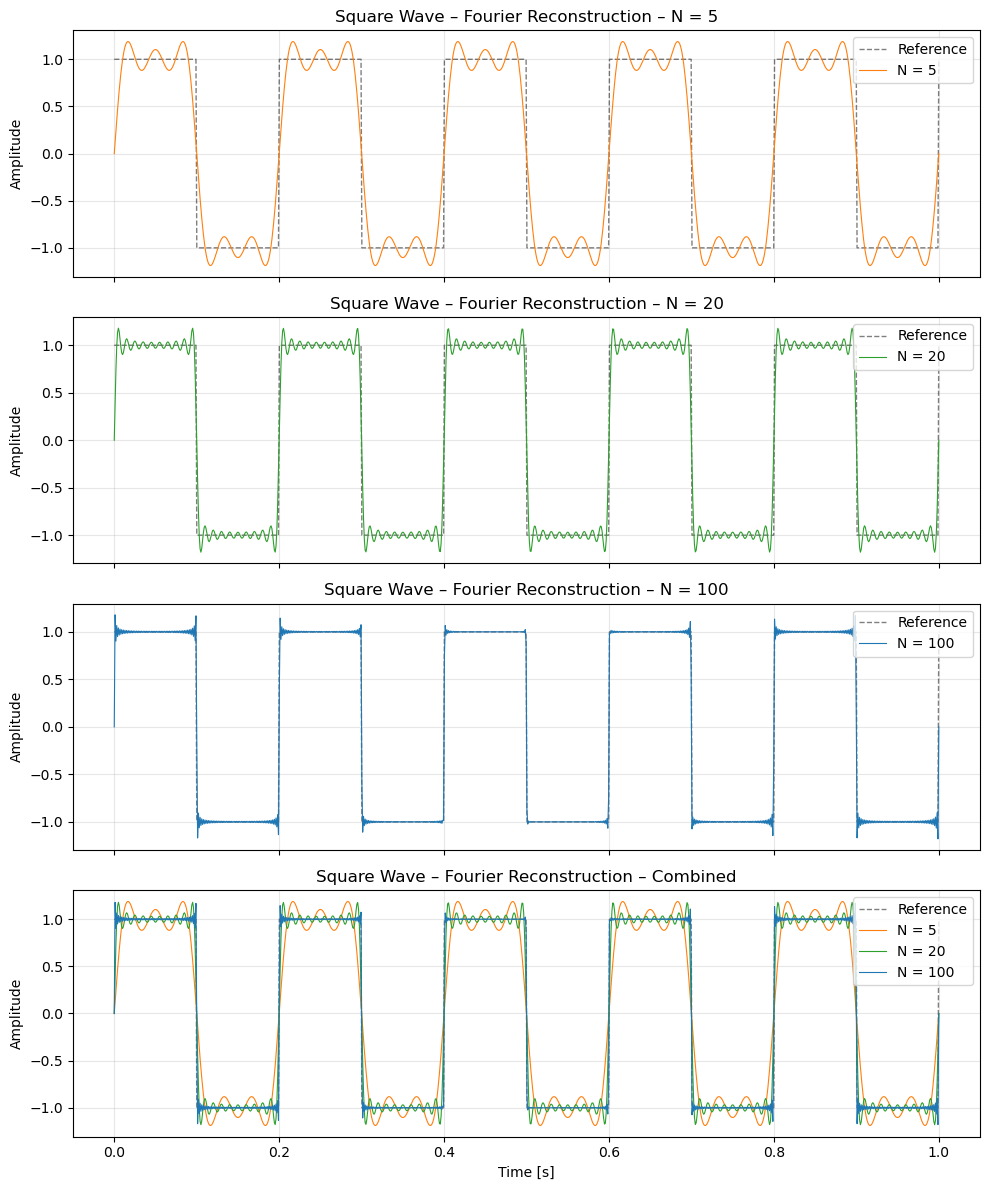

In [18]:
# Square wave reconstruction
plot_reconstruction(t, sq_ref, square_fourier,
                    "Square Wave – Fourier Reconstruction",
                    FIGURES_DIR / "square_reconstruction.png", f0, A);

Saved to /home/Plutonium/Documents/Biosignals/homeworks/fourier_wave_synthesis/figures/triangle_reconstruction.png


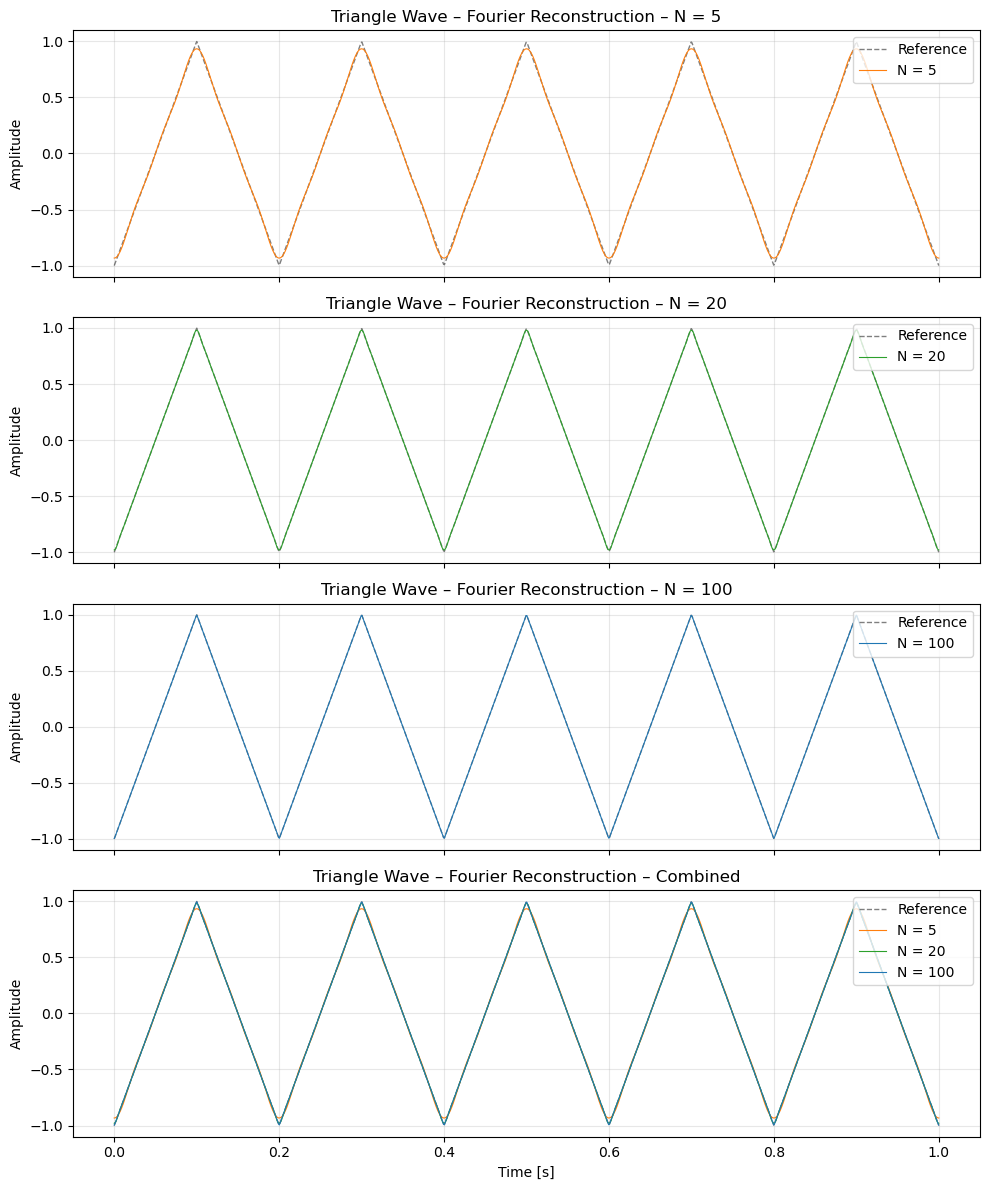

In [19]:
# Triangle wave reconstruction
plot_reconstruction(t, tri_ref, triangle_fourier,
                    "Triangle Wave – Fourier Reconstruction",
                    FIGURES_DIR / "triangle_reconstruction.png", f0, A);

Saved to /home/Plutonium/Documents/Biosignals/homeworks/fourier_wave_synthesis/figures/sawtooth_reconstruction.png


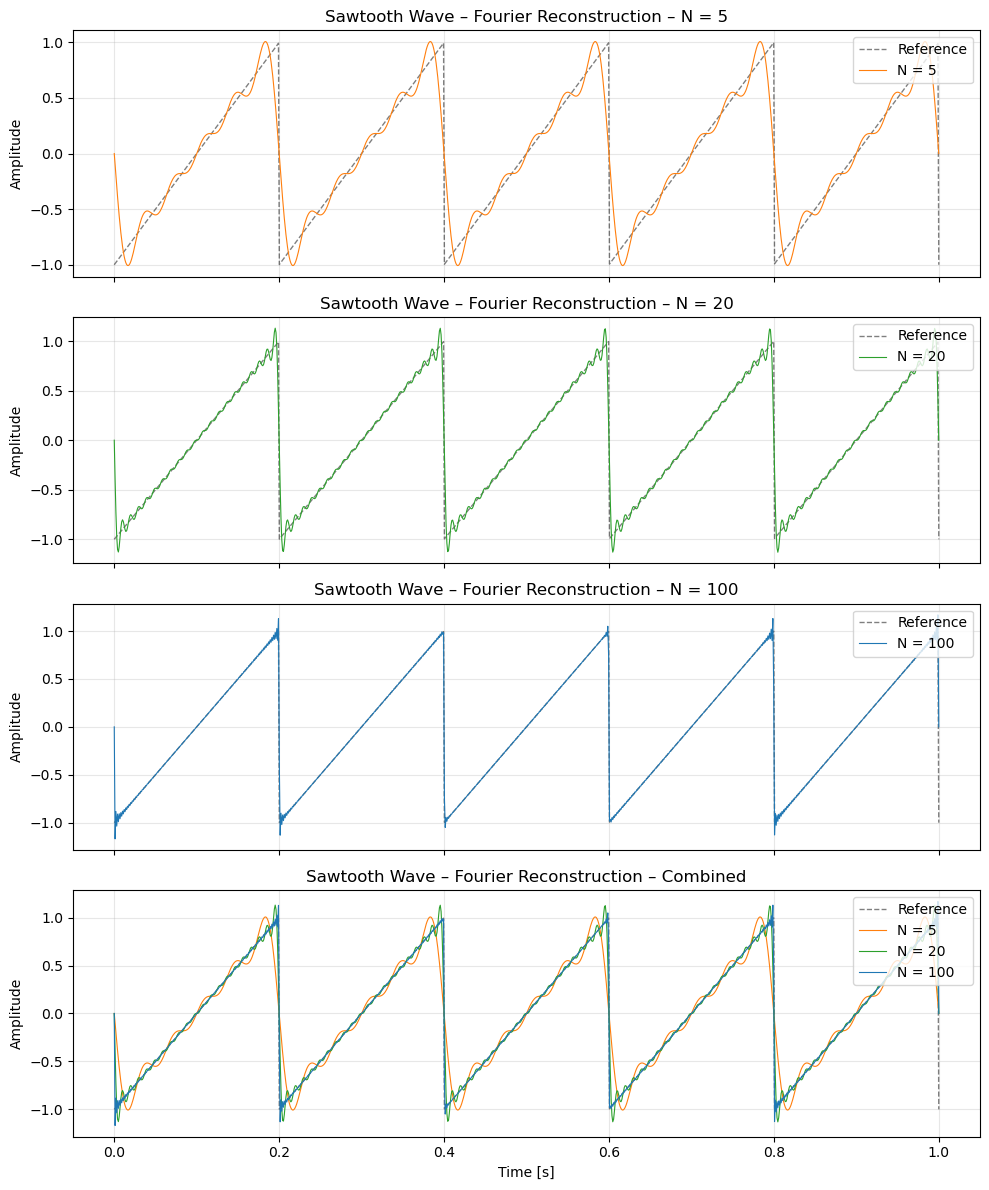

In [20]:
# Sawtooth wave reconstruction
plot_reconstruction(t, saw_ref, sawtooth_fourier,
                    "Sawtooth Wave – Fourier Reconstruction",
                    FIGURES_DIR / "sawtooth_reconstruction.png", f0, A);

## 5. RMS Error Computation

For each waveform, sweep N from 1 to 400 and compute the RMS error between the reference and the Fourier reconstruction at each step.

In [8]:
def compute_rms_sweep(t, ref, fourier_func, N_max, f0=5.0, A=1.0):
    """Compute RMS error for harmonic counts 1 … N_max."""
    harmonics = []
    rms_values = []
    for N in range(1, N_max + 1):
        x_recon = fourier_func(t, N, f0, A)
        rms = rms_error(ref, x_recon)
        harmonics.append(N)
        rms_values.append(rms)
    return pd.DataFrame({"harmonics": harmonics, "rms_error": rms_values})

print("Computing RMS sweep for all three waveforms (N = 1 → 400)...")
print("This may take a moment.\n")

Computing RMS sweep for all three waveforms (N = 1 → 400)...
This may take a moment.



In [9]:
# Square wave RMS
print("Square wave...")
df_sq = compute_rms_sweep(t, sq_ref, square_fourier, N_max, f0, A)
df_sq.to_csv(DATA_DIR / "square_rms.csv", index=False)
print(f"  RMS @ N=1:   {df_sq['rms_error'].iloc[0]:.4f}")
print(f"  RMS @ N=400: {df_sq['rms_error'].iloc[-1]:.4f}")

Square wave...
  RMS @ N=1:   0.4362
  RMS @ N=400: 0.0478


In [10]:
# Triangle wave RMS
print("Triangle wave...")
df_tri = compute_rms_sweep(t, tri_ref, triangle_fourier, N_max, f0, A)
df_tri.to_csv(DATA_DIR / "triangle_rms.csv", index=False)
print(f"  RMS @ N=1:   {df_tri['rms_error'].iloc[0]:.4f}")
print(f"  RMS @ N=400: {df_tri['rms_error'].iloc[-1]:.6f}")

Triangle wave...
  RMS @ N=1:   0.0697
  RMS @ N=400: 0.000050


In [11]:
# Sawtooth wave RMS
print("Sawtooth wave...")
df_saw = compute_rms_sweep(t, saw_ref, sawtooth_fourier, N_max, f0, A)
df_saw.to_csv(DATA_DIR / "sawtooth_rms.csv", index=False)
print(f"  RMS @ N=1:   {df_saw['rms_error'].iloc[0]:.4f}")
print(f"  RMS @ N=400: {df_saw['rms_error'].iloc[-1]:.4f}")

print("\n✓ All CSV files saved to data/.")

Sawtooth wave...
  RMS @ N=1:   0.3627
  RMS @ N=400: 0.0454

✓ All CSV files saved to data/.


## 6. RMS Convergence Plots

Plot how the RMS error decreases as the number of harmonics increases.

In [12]:
def plot_rms(df, title, color, save_path):
    """Plot RMS error vs harmonic count."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df["harmonics"], df["rms_error"], linewidth=0.9, color=color)
    ax.set_title(title)
    ax.set_xlabel("Number of Harmonics (N)")
    ax.set_ylabel("RMS Error")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    print(f"Saved to {save_path}")
    plt.show()
    return fig

Saved to /home/Plutonium/Documents/Biosignals/homeworks/fourier_wave_synthesis/figures/rms_square.png


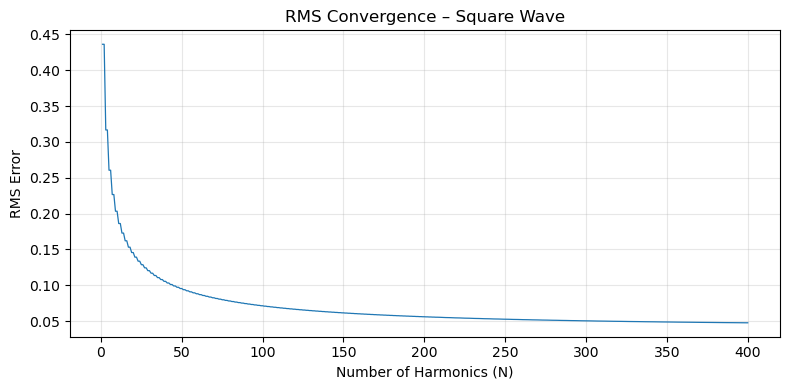

In [13]:
plot_rms(df_sq, "RMS Convergence – Square Wave", "tab:blue",
         FIGURES_DIR / "rms_square.png");

Saved to /home/Plutonium/Documents/Biosignals/homeworks/fourier_wave_synthesis/figures/rms_triangle.png


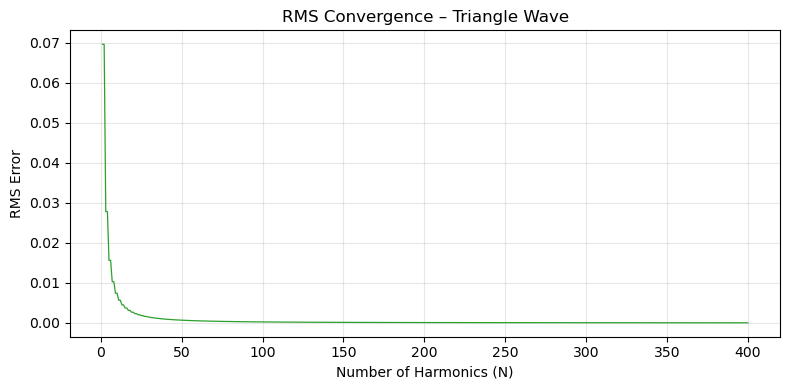

In [14]:
plot_rms(df_tri, "RMS Convergence – Triangle Wave", "tab:green",
         FIGURES_DIR / "rms_triangle.png");

Saved to /home/Plutonium/Documents/Biosignals/homeworks/fourier_wave_synthesis/figures/rms_sawtooth.png


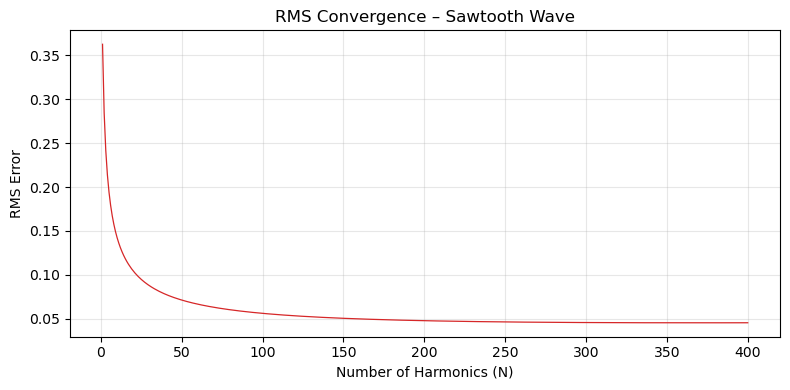

In [15]:
plot_rms(df_saw, "RMS Convergence – Sawtooth Wave", "tab:red",
         FIGURES_DIR / "rms_sawtooth.png");

## 7. Combined RMS Comparison

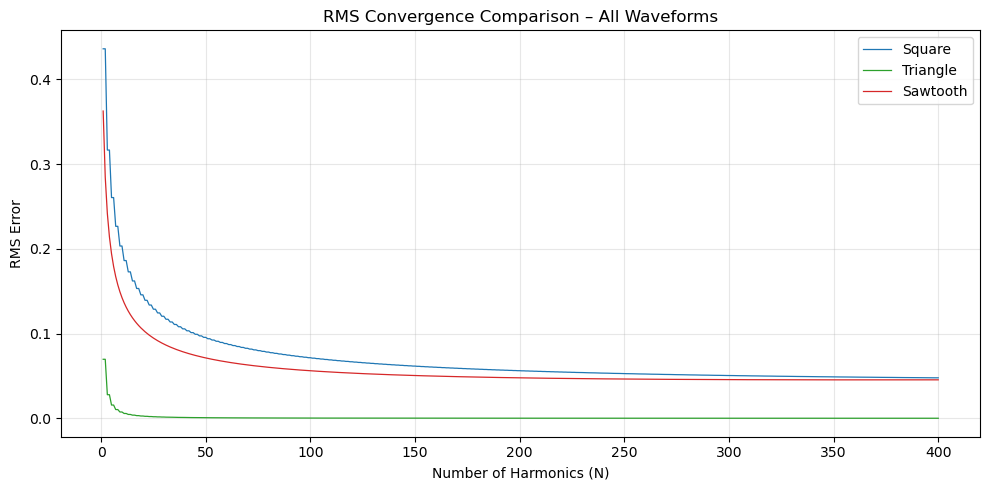

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_sq["harmonics"], df_sq["rms_error"], label="Square", color="tab:blue", linewidth=0.9)
ax.plot(df_tri["harmonics"], df_tri["rms_error"], label="Triangle", color="tab:green", linewidth=0.9)
ax.plot(df_saw["harmonics"], df_saw["rms_error"], label="Sawtooth", color="tab:red", linewidth=0.9)
ax.set_title("RMS Convergence Comparison – All Waveforms")
ax.set_xlabel("Number of Harmonics (N)")
ax.set_ylabel("RMS Error")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Summary & Discussion

### Convergence Behavior

| Waveform | Spectral Decay | Convergence Speed | Gibbs Phenomenon |
|----------|---------------|-------------------|------------------|
| Square   | 1/k           | Slow              | Yes (prominent)  |
| Sawtooth | 1/k           | Slow              | Yes (prominent)  |
| Triangle | 1/k²          | Fast              | No (continuous)  |

### Key Observations

1. **Triangle wave converges fastest** because its Fourier coefficients decay as 1/k² (the signal is continuous and has no discontinuities).
2. **Square and sawtooth waves converge slowly** because their coefficients decay only as 1/k (both have jump discontinuities).
3. **Gibbs phenomenon** is visible as overshoots near the discontinuities of the square and sawtooth waves, even at high harmonic counts. The overshoot settles to ≈ 9% of the step height and does not disappear as N → ∞.
4. All waveforms show monotonically decreasing RMS error as harmonics are added, confirming theoretical Fourier convergence.